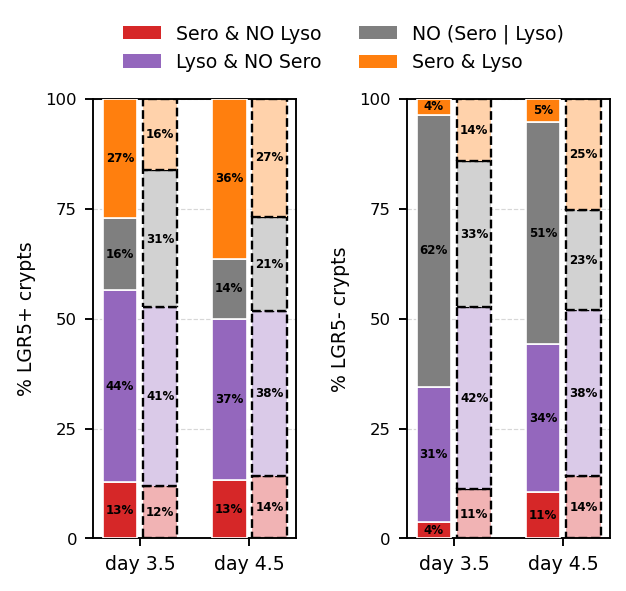

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Paths to your saved coexpression files
# (these are the *_data.npz you saved for the coexpression plot)
# ----------------------------
ds1_npz = "exports/day3p5_filtered_cyclin/coexpression_obs_vs_exp_data.npz"
ds2_npz = "exports/day4p5_filtered_KI67/coexpression_obs_vs_exp_data.npz"

dataset_labels = ["day 3.5", "day 4.5"]


# 4 co-expression labels (used for both LGR5+ and LGR5- panels)
# (this matches your earlier `labels_cond`)
labels_cond = ["Sero & NO Lyso", "Lyso & NO Sero", "NO (Sero | Lyso)", "Sero & Lyso"]

# Optional: fixed colors per category (edit if you want)
cat_colors = ["#d62728", "#9467bd", "#7f7f7f", "#ff7f0e"]


# -----------------------------
# Helpers
# -----------------------------
def load_and_combine_bi_groups(npz_path):
    """
    Loads your saved coexpression NPZ and combines BI=0 and BI>0 groups (no differentiation).
    Assumes the NPZ contains:
      - observed: (G, 8) where G=2 for ["Crypt (BI=0)", "Crypt (BI>0)"] (or similar)
      - Ns:       (G,)
    Returns:
      combined_obs: (8,) category fractions across ALL crypt patches combined,
                    i.e. weighted by Ns.
    """
    d = np.load(npz_path, allow_pickle=True)

    if "observed" not in d or "Ns" not in d:
        raise KeyError(f"{npz_path} must contain 'observed' and 'Ns' arrays.")

    obs = np.asarray(d["observed"], float)   # (G, 8)
    Ns  = np.asarray(d["Ns"], int)           # (G,)

    if obs.ndim != 2 or obs.shape[1] != 8:
        raise ValueError(f"{npz_path}: expected observed shape (G,8), got {obs.shape}")
    if Ns.ndim != 1 or Ns.shape[0] != obs.shape[0]:
        raise ValueError(f"{npz_path}: Ns shape {Ns.shape} incompatible with observed {obs.shape}")

    # Weighted average across groups (because obs rows are fractions within each group)
    w = Ns.astype(float)
    wsum = w.sum()
    if wsum <= 0:
        return np.full(8, np.nan)

    combined_obs = (obs * w[:, None]).sum(axis=0) / wsum
    return combined_obs


def conditional_4way_stack(combined_obs_8, idxs):
    """
    Take 4 categories (either LGR5+ 0..3 or LGR5- 4..7)
    and renormalize so they sum to 1 (100%) within that LGR5 sign.
    """
    v = np.asarray(combined_obs_8, float)[idxs]
    s = np.nansum(v)
    if not np.isfinite(s) or s <= 0:
        return np.full(4, np.nan)
    return v / s


def lgr5_counts_from_observed_row(obs_row_8, N_total):
    """
    obs_row_8: (8,) fractions across the 8 categories within this BI group
    N_total:   int, total patches in this BI group (Ns row)

    Returns: (N_pos, N_neg) integers that sum to N_total.
    """
    obs_row_8 = np.asarray(obs_row_8, float)
    if not np.isfinite(obs_row_8).all() or N_total <= 0:
        return 0, 0

    # expected category counts (float)
    counts = obs_row_8 * float(N_total)

    # LGR5 sign totals (float)
    pos_f = float(np.nansum(counts[:4]))
    neg_f = float(np.nansum(counts[4:]))

    # round, then force sum to match N_total
    N_pos = int(np.rint(pos_f))
    N_neg = int(np.rint(neg_f))

    # fix any rounding drift
    drift = N_total - (N_pos + N_neg)
    if drift != 0:
        # add/subtract drift to the larger group (stable, minimal surprise)
        if pos_f >= neg_f:
            N_pos += drift
        else:
            N_neg += drift

    # clamp
    N_pos = max(N_pos, 0)
    N_neg = max(N_neg, 0)

    # final safety
    if N_pos + N_neg != N_total:
        # last-resort: force exact sum
        N_neg = max(N_total - N_pos, 0)

    return N_pos, N_neg



# -----------------------------
# Load + process both datasets
# -----------------------------
obs1 = load_and_combine_bi_groups(ds1_npz)  # (8,)
obs2 = load_and_combine_bi_groups(ds2_npz)  # (8,)

# LGR5+ categories = 0..3, LGR5- categories = 4..7
stack_pos = np.vstack([
    conditional_4way_stack(obs1, [0, 1, 2, 3]),
    conditional_4way_stack(obs2, [0, 1, 2, 3]),
])  # (2,4)

stack_neg = np.vstack([
    conditional_4way_stack(obs1, [4, 5, 6, 7]),
    conditional_4way_stack(obs2, [4, 5, 6, 7]),
])  # (2,4)


# -----------------------------
# Load + combine BI groups for EXPECTED (same weighted combine as observed)
# -----------------------------
def load_and_combine_bi_groups_expected(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    if "expected" not in d or "Ns" not in d:
        raise KeyError(f"{npz_path} must contain 'expected' and 'Ns' arrays.")
    exp = np.asarray(d["expected"], float)   # (G, 8)
    Ns  = np.asarray(d["Ns"], int)           # (G,)
    w = Ns.astype(float)
    wsum = w.sum()
    if wsum <= 0:
        return np.full(8, np.nan)
    return (exp * w[:, None]).sum(axis=0) / wsum

def conditional_4way_stack(v8, idxs):
    v = np.asarray(v8, float)[idxs]
    s = np.nansum(v)
    if not np.isfinite(s) or s <= 0:
        return np.full(4, np.nan)
    return v / s

# Your two dataset files (same as before)

labels_cond = ["Sero & NO Lyso", "Lyso & NO Sero", "NO (Sero | Lyso)", "Sero & Lyso"]
cat_colors  = ["#d62728", "#9467bd", "#7f7f7f", "#ff7f0e"]

# ---- expected stacks (renormalized within LGR5 sign) ----
exp1 = load_and_combine_bi_groups_expected(ds1_npz)
exp2 = load_and_combine_bi_groups_expected(ds2_npz)

stack_pos_exp = np.vstack([
    conditional_4way_stack(exp1, [0, 1, 2, 3]),
    conditional_4way_stack(exp2, [0, 1, 2, 3]),
])  # (2,4)

stack_neg_exp = np.vstack([
    conditional_4way_stack(exp1, [4, 5, 6, 7]),
    conditional_4way_stack(exp2, [4, 5, 6, 7]),
])  # (2,4)

def lighten_color(rgb_or_hex, amount=0.55):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))

# Previous fig was ~ (5.6, 4.2); apply 40% narrower and 20% shorter:
fig_w, fig_h = 5.6 * 0.70, 4.2 * 0.80  # = (3.36, 3.36)
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), dpi=170)

# (2) increase gap between subplots
fig.subplots_adjust(wspace=0.55)

# (3) datasets closer together by shrinking their x-centers distance
x = np.array([0.00, 0.95])   # <--- closer than [0, 1]
# keep the obs/exp pairing separation as before (or slightly smaller if you want)
dx = 0.175
x_obs = x - dx
x_exp = x + dx

# keep bar width SAME as before
w = 0.30

light_colors = [lighten_color(c, 0.65) for c in cat_colors]

def stacked_pair(ax, obs_2x4, exp_2x4, ylabel):
    bot_obs = np.zeros(2, dtype=float)
    bot_exp = np.zeros(2, dtype=float)

    for ci in range(4):
        # convert to percent
        v_obs = 100.0 * obs_2x4[:, ci]
        v_exp = 100.0 * exp_2x4[:, ci]

        # Observed (solid)
        bars_obs = ax.bar(
            x_obs, v_obs, width=w, bottom=bot_obs,
            color=cat_colors[ci], edgecolor="white", linewidth=0.7,
            zorder=3,
        )

        # Expected (lighter fill + dashed outline)
        bars_exp = ax.bar(
            x_exp, v_exp, width=w, bottom=bot_exp,
            color=light_colors[ci], edgecolor="black", linewidth=1.0,
            linestyle="--",
            zorder=2,
        )

        # % labels inside segments (Observed)
        for rect, v, btm in zip(bars_obs, v_obs, bot_obs):
            if not np.isfinite(v) or v <= 0:
                continue
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                btm + v / 2,
                f"{v:.0f}%",
                ha="center", va="center",
                color="black", fontsize=5, fontweight="bold",
                clip_on=True, zorder=4,
            )

        # % labels inside segments (Expected)
        for rect, v, btm in zip(bars_exp, v_exp, bot_exp):
            if not np.isfinite(v) or v <= 0:
                continue
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                btm + v / 2,
                f"{v:.0f}%",
                ha="center", va="center",
                color="black", fontsize=5, fontweight="bold",
                clip_on=True, zorder=4,
            )

        bot_obs = bot_obs + np.nan_to_num(v_obs, nan=0.0)
        bot_exp = bot_exp + np.nan_to_num(v_exp, nan=0.0)

    # (4) y-axis in percent
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    # x ticks at dataset centers, with labels
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_labels, fontsize=8)

    # (5) y-label only (no titles)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)   # change 11 to what you want

# left: LGR5+, right: LGR5-
stacked_pair(axes[0], stack_pos, stack_pos_exp, "% LGR5+ crypts")
stacked_pair(axes[1], stack_neg, stack_neg_exp, "% LGR5- crypts")

# One legend for the 4 categories only (kept, since you didn't ask to remove it)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=cat_colors[i]) for i in range(4)]
fig.legend(
    handles, labels_cond,
    frameon=False, ncol=2,
    loc="upper center", bbox_to_anchor=(0.5, 1.04),
    fontsize=8
)

plt.show()


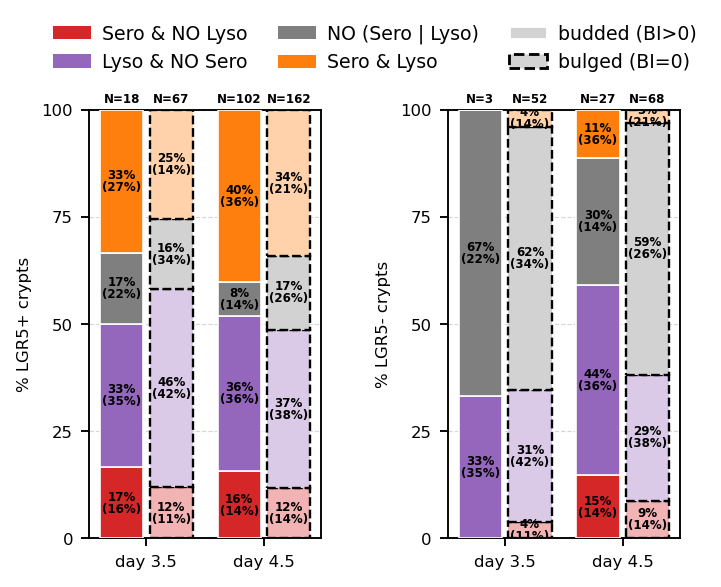

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------
ds1_npz = "exports/day3p5_filtered_cyclin/coexpression_obs_vs_exp_data.npz"
ds2_npz = "exports/day4p5_filtered_KI67/coexpression_obs_vs_exp_data.npz"

dataset_labels = ["day 3.5", "day 4.5"]

labels_cond = ["Sero & NO Lyso", "Lyso & NO Sero", "NO (Sero | Lyso)", "Sero & Lyso"]
cat_colors  = ["#d62728", "#9467bd", "#7f7f7f", "#ff7f0e"]


# -----------------------------
# Helpers
# -----------------------------
def lighten_color(rgb_or_hex, amount=0.65):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))

def conditional_4way_stack(v8, idxs):
    """Renormalize selected 4 entries to sum to 1 (within LGR5 sign)."""
    v = np.asarray(v8, float)[idxs]
    s = np.nansum(v)
    if not np.isfinite(s) or s <= 0:
        return np.full(4, np.nan)
    return v / s

def load_bi_split(npz_path):
    """
    Loads NPZ and returns BI=0 and BI>0 separately.
    Assumes row 0 = BI=0 and row 1 = BI>0 in observed/expected/Ns.
    """
    d = np.load(npz_path, allow_pickle=True)
    for key in ("observed", "expected", "Ns"):
        if key not in d:
            raise KeyError(f"{npz_path} must contain '{key}'")

    obs = np.asarray(d["observed"], float)  # (G,8)
    exp = np.asarray(d["expected"], float)  # (G,8)
    Ns  = np.asarray(d["Ns"], int)          # (G,)

    if obs.ndim != 2 or obs.shape[1] != 8:
        raise ValueError(f"{npz_path}: expected observed shape (G,8), got {obs.shape}")
    if exp.shape != obs.shape:
        raise ValueError(f"{npz_path}: expected expected shape {obs.shape}, got {exp.shape}")
    if Ns.ndim != 1 or Ns.shape[0] != obs.shape[0]:
        raise ValueError(f"{npz_path}: Ns shape {Ns.shape} incompatible with observed {obs.shape}")
    if obs.shape[0] < 2:
        raise ValueError(f"{npz_path}: need at least 2 rows (BI=0 and BI>0). Got {obs.shape[0]}.")

    # row0=BI=0 (bulged), row1=BI>0 (budded)
    return obs[0], obs[1], exp[0], exp[1], int(Ns[0]), int(Ns[1])


# -----------------------------
# Load datasets (BI split)
# -----------------------------
obs1_bi0, obs1_bipos, exp1_bi0, exp1_bipos, n1_bi0, n1_bipos = load_bi_split(ds1_npz)
obs2_bi0, obs2_bipos, exp2_bi0, exp2_bipos, n2_bi0, n2_bipos = load_bi_split(ds2_npz)

# BI>0 (budded) = dark/solid bars
# BI=0 (bulged) = light + dashed-outline bars
# totals per BI group per dataset
Ns_bipos_total = np.array([n1_bipos, n2_bipos], dtype=int)
Ns_bi0_total   = np.array([n1_bi0,   n2_bi0],   dtype=int)

# derive sign-specific Ns from observed fractions
n1_pos_bipos, n1_neg_bipos = lgr5_counts_from_observed_row(obs1_bipos, n1_bipos)
n2_pos_bipos, n2_neg_bipos = lgr5_counts_from_observed_row(obs2_bipos, n2_bipos)

n1_pos_bi0,   n1_neg_bi0   = lgr5_counts_from_observed_row(obs1_bi0, n1_bi0)
n2_pos_bi0,   n2_neg_bi0   = lgr5_counts_from_observed_row(obs2_bi0, n2_bi0)

Ns_bipos_pos = np.array([n1_pos_bipos, n2_pos_bipos], dtype=int)
Ns_bipos_neg = np.array([n1_neg_bipos, n2_neg_bipos], dtype=int)

Ns_bi0_pos   = np.array([n1_pos_bi0,   n2_pos_bi0],   dtype=int)
Ns_bi0_neg   = np.array([n1_neg_bi0,   n2_neg_bi0],   dtype=int)


# -----------------------------
# Build stacks (2 datasets x 4 cats) for each LGR5 sign and BI group
# -----------------------------
# LGR5+ categories = 0..3; LGR5- categories = 4..7
stack_pos_bipos = np.vstack([
    conditional_4way_stack(obs1_bipos, [0, 1, 2, 3]),
    conditional_4way_stack(obs2_bipos, [0, 1, 2, 3]),
])  # (2,4)
stack_pos_bi0 = np.vstack([
    conditional_4way_stack(obs1_bi0, [0, 1, 2, 3]),
    conditional_4way_stack(obs2_bi0, [0, 1, 2, 3]),
])  # (2,4)

stack_neg_bipos = np.vstack([
    conditional_4way_stack(obs1_bipos, [4, 5, 6, 7]),
    conditional_4way_stack(obs2_bipos, [4, 5, 6, 7]),
])  # (2,4)
stack_neg_bi0 = np.vstack([
    conditional_4way_stack(obs1_bi0, [4, 5, 6, 7]),
    conditional_4way_stack(obs2_bi0, [4, 5, 6, 7]),
])  # (2,4)

# Expected only for text (same BI group, renormalized within LGR5 sign)
exp_pos_bipos = np.vstack([
    conditional_4way_stack(exp1_bipos, [0, 1, 2, 3]),
    conditional_4way_stack(exp2_bipos, [0, 1, 2, 3]),
])  # (2,4)
exp_pos_bi0 = np.vstack([
    conditional_4way_stack(exp1_bi0, [0, 1, 2, 3]),
    conditional_4way_stack(exp2_bi0, [0, 1, 2, 3]),
])  # (2,4)

exp_neg_bipos = np.vstack([
    conditional_4way_stack(exp1_bipos, [4, 5, 6, 7]),
    conditional_4way_stack(exp2_bipos, [4, 5, 6, 7]),
])  # (2,4)
exp_neg_bi0 = np.vstack([
    conditional_4way_stack(exp1_bi0, [4, 5, 6, 7]),
    conditional_4way_stack(exp2_bi0, [4, 5, 6, 7]),
])  # (2,4)


# -----------------------------
# Plot layout (keeps your current styling choices)
# -----------------------------
fig_w, fig_h = 5.6 * 0.80, 4.2 * 0.80
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), dpi=170)

# More room on top for outside-N labels
fig.subplots_adjust(wspace=0.55, top=0.86)

# Dataset centers and bar offsets (your manual tweaks)
x = np.array([0.00, 0.95])
dx = 0.2
x_dark  = x - dx   # BI>0 (budded) -> dark/solid
x_light = x + dx   # BI=0 (bulged) -> light/dashed

w = 0.35  # bar width

light_colors = [lighten_color(c, amount=0.65) for c in cat_colors]


def stacked_bi_pair(ax,
                    obs_dark, exp_dark, N_dark,
                    obs_light, exp_light, N_light,
                    ylabel):

    bot_dark  = np.zeros(2, dtype=float)
    bot_light = np.zeros(2, dtype=float)

    for ci in range(4):
        # convert to percent
        v_dark  = 100.0 * obs_dark[:, ci]
        v_light = 100.0 * obs_light[:, ci]
        e_dark  = 100.0 * exp_dark[:, ci]
        e_light = 100.0 * exp_light[:, ci]

        # Dark / solid (BI>0, budded)
        bars_dark = ax.bar(
            x_dark, v_dark, width=w, bottom=bot_dark,
            color=cat_colors[ci], edgecolor="white", linewidth=0.7,
            zorder=3,
        )

        # Light / dashed outline (BI=0, bulged)
        bars_light = ax.bar(
            x_light, v_light, width=w, bottom=bot_light,
            color=light_colors[ci], edgecolor="black", linewidth=1.0,
            linestyle="--",
            zorder=2,
        )

        # Two-line labels inside segments: observed on top, expected below
        for rect, vo, ve, btm in zip(bars_dark, v_dark, e_dark, bot_dark):
            if not np.isfinite(vo) or vo <= 0:
                continue
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                btm + vo / 2,
                f"{vo:.0f}%\n({ve:.0f}%)",
                ha="center", va="center",
                color="black", fontsize=5, fontweight="bold",
                linespacing=0.9,
                clip_on=True, zorder=4,
            )

        for rect, vo, ve, btm in zip(bars_light, v_light, e_light, bot_light):
            if not np.isfinite(vo) or vo <= 0:
                continue
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                btm + vo / 2,
                f"{vo:.0f}%\n({ve:.0f}%)",
                ha="center", va="center",
                color="black", fontsize=5, fontweight="bold",
                linespacing=0.9,
                clip_on=True, zorder=4,
            )

        bot_dark  = bot_dark  + np.nan_to_num(v_dark, nan=0.0)
        bot_light = bot_light + np.nan_to_num(v_light, nan=0.0)

    # ---- N labels above bars, outside plot area (no y-axis extension) ----
    trans = ax.get_xaxis_transform()  # x in data coords, y in axes coords
    for j in range(len(x_dark)):
        ax.text(
            x_dark[j], 1.01, f"N={int(N_dark[j])}",
            transform=trans, ha="center", va="bottom",
            fontsize=5, fontweight="bold",
            clip_on=False
        )
        ax.text(
            x_light[j], 1.01, f"N={int(N_light[j])}",
            transform=trans, ha="center", va="bottom",
            fontsize=5, fontweight="bold",
            clip_on=False
        )

    # Axis styling (keep 0..100 exactly)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_labels, fontsize=7)

    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(axis="y", labelsize=7)


# left: LGR5+, right: LGR5-
# LGR5+ subplot: use Ns_*_pos
stacked_bi_pair(
    axes[0],
    obs_dark=stack_pos_bipos, exp_dark=exp_pos_bipos, N_dark=Ns_bipos_pos,
    obs_light=stack_pos_bi0,  exp_light=exp_pos_bi0,  N_light=Ns_bi0_pos,
    ylabel="% LGR5+ crypts",
)

# LGR5- subplot: use Ns_*_neg
stacked_bi_pair(
    axes[1],
    obs_dark=stack_neg_bipos, exp_dark=exp_neg_bipos, N_dark=Ns_bipos_neg,
    obs_light=stack_neg_bi0,  exp_light=exp_neg_bi0,  N_light=Ns_bi0_neg,
    ylabel="% LGR5- crypts",
)


# Legend for the 4 categories
handles = (
    [plt.Rectangle((0, 0), 1, 1, facecolor=cat_colors[i], edgecolor="none") for i in range(4)]
    + [
        plt.Rectangle((0, 0), 1, 1, facecolor="lightgray", edgecolor="white", linewidth=1.2),                 # budded (solid)
        plt.Rectangle((0, 0), 1, 1, facecolor="lightgray", edgecolor="black", linewidth=1.2, linestyle="--") # bulged (dashed)
    ]
)

labels = labels_cond + ["budded (BI>0)", "bulged (BI=0)"]

fig.legend(
    handles, labels,
    frameon=False,
    ncol=3,                      # keep compact; bump to 3 if you prefer
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    fontsize=8,
    columnspacing=1.6,
    handletextpad=0.6,
)


fig.savefig("exports/crypt_composition_coex.pdf", format="pdf", bbox_inches="tight")

plt.show()



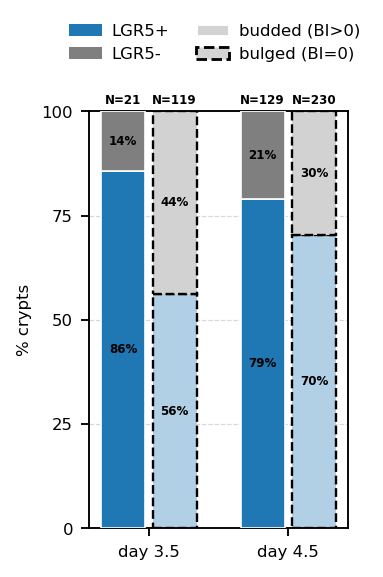

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------
ds1_npz = "exports/day3p5_filtered_cyclin/coexpression_obs_vs_exp_data.npz"
ds2_npz = "exports/day4p5_filtered_KI67/coexpression_obs_vs_exp_data.npz"
dataset_labels = ["day 3.5", "day 4.5"]

# ----------------------------
# Helpers
# ----------------------------
def lighten_color(rgb_or_hex, amount=0.65):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))

def load_bi_split(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    obs = np.asarray(d["observed"], float)
    Ns  = np.asarray(d["Ns"], int)
    if obs.ndim != 2 or obs.shape[1] != 8 or obs.shape[0] < 2:
        raise ValueError(f"{npz_path}: expected observed shape (>=2,8), got {obs.shape}")
    return obs[0], obs[1], int(Ns[0]), int(Ns[1])  # BI=0, BI>0

def lgr5_split_from_obs(obs8):
    p_pos = np.nansum(obs8[:4])
    p_neg = np.nansum(obs8[4:])
    s = p_pos + p_neg
    if not np.isfinite(s) or s <= 0:
        return np.nan, np.nan
    return p_pos/s, p_neg/s


# ----------------------------
# Load data
# ----------------------------
obs1_bi0, obs1_bipos, n1_bi0, n1_bipos = load_bi_split(ds1_npz)
obs2_bi0, obs2_bipos, n2_bi0, n2_bipos = load_bi_split(ds2_npz)

Ns_bipos = np.array([n1_bipos, n2_bipos])
Ns_bi0   = np.array([n1_bi0,   n2_bi0])

stack_bipos = np.vstack([
    lgr5_split_from_obs(obs1_bipos),
    lgr5_split_from_obs(obs2_bipos),
])
stack_bi0 = np.vstack([
    lgr5_split_from_obs(obs1_bi0),
    lgr5_split_from_obs(obs2_bi0),
])

# ----------------------------
# Plot
# ----------------------------
fig_w, fig_h = 5.6 * 0.35, 4.2 * 0.80
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=170)
fig.subplots_adjust(top=0.84)

x = np.array([0.00, 0.95])
dx = 0.175
x_dark  = x - dx
x_light = x + dx
w = 0.30

seg_labels = ["LGR5+", "LGR5-"]
seg_colors = ["#1f77b4", "#7f7f7f"]
seg_colors_light = [lighten_color(c, 0.65) for c in seg_colors]

def stacked_two(ax, x0, stacks, colors, edgecolor, linestyle, zorder):
    bottom = np.zeros(2)
    for si in range(2):
        v = 100 * stacks[:, si]
        bars = ax.bar(
            x0, v, width=w, bottom=bottom,
            color=colors[si],
            edgecolor=edgecolor,
            linewidth=1.0 if linestyle=="--" else 0.7,
            linestyle=linestyle,
            zorder=zorder
        )
        for rect, vv, btm in zip(bars, v, bottom):
            if vv <= 0: continue
            ax.text(rect.get_x()+rect.get_width()/2, btm+vv/2,
                    f"{vv:.0f}%", ha="center", va="center",
                    fontsize=5, fontweight="bold",
                    color="black", clip_on=True, zorder=zorder+1)
        bottom += np.nan_to_num(v)

# Draw bars
stacked_two(ax, x_dark,  stack_bipos, seg_colors,       edgecolor="white", linestyle="-",  zorder=3)
stacked_two(ax, x_light, stack_bi0,   seg_colors_light, edgecolor="black", linestyle="--", zorder=2)

# N labels above bars (outside axes)
trans = ax.get_xaxis_transform()
for j in range(len(x)):
    ax.text(x_dark[j],  1.01, f"N={Ns_bipos[j]}", transform=trans,
            ha="center", va="bottom", fontsize=5, fontweight="bold", clip_on=False)
    ax.text(x_light[j], 1.01, f"N={Ns_bi0[j]}", transform=trans,
            ha="center", va="bottom", fontsize=5, fontweight="bold", clip_on=False)

# Axis styling
ax.set_ylim(0, 100)
ax.set_yticks([0,25,50,75,100])
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(dataset_labels, fontsize=7)
ax.set_ylabel("% crypts", fontsize=7)
ax.tick_params(axis="y", labelsize=7)

# ----------------------------
# Combined legend — all boxes
# ----------------------------
handles = [
    plt.Rectangle((0,0),1,1, facecolor=seg_colors[0], edgecolor="none"),
    plt.Rectangle((0,0),1,1, facecolor=seg_colors[1], edgecolor="none"),
    plt.Rectangle((0,0),1,1, facecolor="lightgray", edgecolor="white", linewidth=1.2),
    plt.Rectangle((0,0),1,1, facecolor="lightgray", edgecolor="black", linewidth=1.2, linestyle="--"),
]
labels = [
    "LGR5+",
    "LGR5-",
    "budded (BI>0)",
    "bulged (BI=0)",
]

fig.legend(
    handles, labels,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=7,
    columnspacing=1.6,
    handletextpad=0.6,
)

fig.savefig("exports/crypt_composition_LGR5.pdf", format="pdf", bbox_inches="tight")

plt.show()
